# Individual Task 1 — Part 1.3: Data Analysis
**Sahana Nataraja (s4164152)** — Case Studies in Data Science

Two publicly available datasets, two machine learning algorithms each.

| | Dataset A | Dataset B |
|---|---|---|
| Source | UCI Online Retail II | UCI Online Shoppers Purchasing Intention |
| Task | Weekly product demand (regression) | Session conversion (classification) |
| Models | Random Forest, Gradient Boosting | Random Forest, Gradient Boosting |
| Metrics | MAE, RMSE, WAPE | PR-AUC, ROC-AUC, F1 |

Both algorithms are new relative to previous coursework (kNN, SVM, neural networks).

## 1. Setup


In [14]:
import importlib, subprocess, sys

for mod, pkg in [("pandas","pandas"), ("numpy","numpy"), ("sklearn","scikit-learn"),
                 ("matplotlib","matplotlib"), ("openpyxl","openpyxl")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        print(f"installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import (
    RandomForestRegressor, HistGradientBoostingRegressor,
    RandomForestClassifier, HistGradientBoostingClassifier,
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    average_precision_score, roc_auc_score, f1_score,
    precision_recall_curve, confusion_matrix, classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
os.makedirs("figures", exist_ok=True)
%matplotlib inline
print("ready - all packages present")


ready - all packages present


## 2. Download the data

- Online Retail II — https://archive.ics.uci.edu/dataset/502/online+retail+ii
- Online Shoppers — https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

In [17]:
import urllib.request, zipfile, io

FILES = {
    "online_retail_II.xlsx":
        "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip",
    "online_shoppers_intention.csv":
        "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
}

for target, url in FILES.items():
    if os.path.exists(target):
        print(f"already have {target}")
        continue
    try:
        print(f"downloading {target} ...")
        with urllib.request.urlopen(url, timeout=120) as r:
            zipfile.ZipFile(io.BytesIO(r.read())).extractall(".")
        print(f"  -> {'ok' if os.path.exists(target) else 'extracted, check filename'}")
    except Exception as e:
        print(f"  -> FAILED ({e}). Download manually, see cell above.")

print("\nfiles present:", [f for f in os.listdir('.') if f.endswith(('.xlsx', '.csv'))])


already have online_retail_II.xlsx
already have online_shoppers_intention.csv

files present: ['results_dataset_b.csv', 'results_dataset_a.csv', 'online_retail_II.xlsx', 'online_shoppers_intention.csv']


## 3. Load

In [20]:
def load_retail(path="online_retail_II.xlsx"):
    """Online Retail II. Two sheets: 2009-2010 and 2010-2011. Concatenate both."""
    sheets = pd.read_excel(path, sheet_name=None)
    df = pd.concat(sheets.values(), ignore_index=True)
    df.columns = [c.strip() for c in df.columns]
    df = df.rename(columns={"Customer ID": "CustomerID"})
    return df

def load_sessions(path="online_shoppers_intention.csv"):
    return pd.read_csv(path)

retail_raw = load_retail()
sessions_raw = load_sessions()
print("retail:  ", retail_raw.shape)
print("sessions:", sessions_raw.shape)
retail_raw.head()


retail:   (1067371, 8)
sessions: (12330, 18)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 4. Dataset A — cleaning and panel construction

In [22]:
def clean_retail(df):
    """Cancellations, returns and bad prices are removed before modelling."""
    n0 = len(df)
    df = df.copy()
    df["Invoice"] = df["Invoice"].astype(str)
    df = df[~df["Invoice"].str.startswith("C")]        # cancellations
    df = df[df["Quantity"] > 0]                         # returns / adjustments
    df = df[df["Price"] > 0]                            # freebies, data errors
    df = df.dropna(subset=["StockCode", "InvoiceDate"])
    df["StockCode"] = df["StockCode"].astype(str).str.upper().str.strip()
    non_product = {"POST", "D", "DOT", "M", "S", "AMAZONFEE", "BANK CHARGES",
                   "C2", "CRUK", "PADS", "B", "GIFT"}
    df = df[~df["StockCode"].isin(non_product)]
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
    df["Revenue"] = df["Quantity"] * df["Price"]
    print(f"[A] cleaning: {n0:,} -> {len(df):,} rows "
          f"({100*(n0-len(df))/n0:.1f}% removed)")
    return df

def build_weekly_panel(df, top_n=300):
    """Product-week panel for the top N products by revenue.

    Zero-demand weeks are explicitly filled: a week with no sales is a real
    observation, not a missing one, and dropping them would bias the model
    toward optimism.
    """
    top = (df.groupby("StockCode")["Revenue"].sum()
             .nlargest(top_n).index)
    d = df[df["StockCode"].isin(top)].copy()
    d["Week"] = d["InvoiceDate"].dt.to_period("W").dt.start_time

    panel = (d.groupby(["StockCode", "Week"])
               .agg(Quantity=("Quantity", "sum"),
                    Price=("Price", "mean"),
                    Invoices=("Invoice", "nunique"))
               .reset_index())

    weeks = pd.date_range(panel["Week"].min(), panel["Week"].max(), freq="W-MON")
    grid = pd.MultiIndex.from_product(
        [panel["StockCode"].unique(), weeks], names=["StockCode", "Week"]
    ).to_frame(index=False)
    panel = grid.merge(panel, on=["StockCode", "Week"], how="left")
    panel["Quantity"] = panel["Quantity"].fillna(0)
    panel["Invoices"] = panel["Invoices"].fillna(0)
    panel = panel.sort_values(["StockCode", "Week"])
 
    panel["Price"] = panel.groupby("StockCode")["Price"].ffill()
    panel["Price"] = panel.groupby("StockCode")["Price"].bfill()
    panel = panel.dropna(subset=["Price"])
    print(f"[A] panel: {panel['StockCode'].nunique()} products x "
          f"{panel['Week'].nunique()} weeks = {len(panel):,} rows")
    return panel

retail = clean_retail(retail_raw)
panel_raw = build_weekly_panel(retail, top_n=300)
panel_raw.head()


[A] cleaning: 1,067,371 -> 1,037,130 rows (2.8% removed)
[A] panel: 300 products x 106 weeks = 31,800 rows


,StockCode,Week,Quantity,Price,Invoices
0,15036,2009-11-30,337.0,0.872500,8.0
1,15036,2009-12-07,103.0,1.056250,8.0
2,15036,2009-12-14,63.0,1.155556,9.0
3,15036,2009-12-21,103.0,1.170000,5.0
4,15036,2009-12-28,0.0,1.170000,0.0


## 5. Dataset A — feature engineering

In [24]:
def engineer_demand_features(panel):
    """Lags, rolling demand, relative price and calendar effects."""
    p = panel.sort_values(["StockCode", "Week"]).copy()
    g = p.groupby("StockCode")

    for lag in (1, 2, 4):
        p[f"qty_lag{lag}"] = g["Quantity"].shift(lag)
    p["qty_roll4"] = g["Quantity"].shift(1).rolling(4).mean().reset_index(0, drop=True)
    p["qty_roll8"] = g["Quantity"].shift(1).rolling(8).mean().reset_index(0, drop=True)
    p["price_lag1"] = g["Price"].shift(1)

    p["invoices_lag1"] = g["Invoices"].shift(1)

    p["price_median"] = g["Price"].transform("median")
    p["price_rel"] = p["Price"] / p["price_median"]
    p["price_change"] = (p["Price"] - p["price_lag1"]) / p["price_lag1"]

    p["week_of_year"] = p["Week"].dt.isocalendar().week.astype(int)
    p["month"] = p["Week"].dt.month
    p["is_q4"] = p["month"].isin([10, 11, 12]).astype(int)

    p = p.dropna(subset=["qty_lag1", "qty_lag2", "qty_lag4", "qty_roll4",
                         "qty_roll8", "price_change", "invoices_lag1"])
    p = p.replace([np.inf, -np.inf], np.nan).dropna()
    return p

panel = engineer_demand_features(panel_raw)
print(panel.shape)
panel[["StockCode","Week","Quantity","Price","price_rel","qty_lag1","qty_roll4"]].head()


(29400, 18)


,StockCode,Week,Quantity,Price,price_rel,qty_lag1,qty_roll4
8,15036,2010-01-25,59.0,0.920000,0.914923,118.0,85.00
9,15036,2010-02-01,36.0,0.590000,0.586744,59.0,99.75
10,15036,2010-02-08,98.0,0.965000,0.959674,36.0,60.75
11,15036,2010-02-15,214.0,0.755000,0.750833,98.0,77.75
12,15036,2010-02-22,103.0,0.855714,0.850992,214.0,101.75


## 6. Dataset A — modelling

Split is **temporal**, not random: a random split would leak future demand into the past.

**Why WAPE over MAPE:** product-weeks with zero or near-zero demand make MAPE undefined or
explosive. WAPE weights error by volume, which matches the commercial reality that being
wrong on a high-volume line costs more. The naive lag-1 baseline is included so that model
performance means something.

In [26]:
def wape(y_true, y_pred):
    """Weighted absolute percentage error.

    Chosen over MAPE because product-weeks with zero or near-zero demand make
    MAPE undefined or explosive. WAPE weights error by volume, which is the
    commercially meaningful view: being wrong on a high-volume line costs more.
    """
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

def run_dataset_a(panel):
    FEATURES = ["qty_lag1", "qty_lag2", "qty_lag4", "qty_roll4", "qty_roll8",
                "Price", "price_rel", "price_change", "invoices_lag1",
                "week_of_year", "month", "is_q4"]
    TARGET = "Quantity"

    cutoff = panel["Week"].quantile(0.8)
    train = panel[panel["Week"] <= cutoff]
    test = panel[panel["Week"] > cutoff]
    print(f"[A] split at {cutoff.date()}: train={len(train):,} test={len(test):,}")

    X_tr, y_tr = train[FEATURES], train[TARGET]
    X_te, y_te = test[FEATURES], test[TARGET]

    models = {
        "Random Forest": RandomForestRegressor(
            n_estimators=300, min_samples_leaf=3, n_jobs=-1,
            random_state=RANDOM_STATE),
        "Gradient Boosting": HistGradientBoostingRegressor(
            max_iter=400, learning_rate=0.06, min_samples_leaf=20,
            random_state=RANDOM_STATE),
    }

    rows = []
    preds = {}

    rows.append({"Model": "Naive (lag-1)",
                 "MAE": mean_absolute_error(y_te, X_te["qty_lag1"]),
                 "RMSE": np.sqrt(mean_squared_error(y_te, X_te["qty_lag1"])),
                 "WAPE": wape(y_te, X_te["qty_lag1"])})

    for name, model in models.items():
        model.fit(X_tr, y_tr)
        pred = np.clip(model.predict(X_te), 0, None)   # demand cannot be negative
        preds[name] = pred
        rows.append({"Model": name,
                     "MAE": mean_absolute_error(y_te, pred),
                     "RMSE": np.sqrt(mean_squared_error(y_te, pred)),
                     "WAPE": wape(y_te, pred)})

    results = pd.DataFrame(rows).set_index("Model").round(3)
    print("\n[A] DEMAND FORECASTING RESULTS\n", results, "\n")

    best = min(models, key=lambda m: wape(y_te, preds[m]))
    imp = permutation_importance(models[best], X_te, y_te, n_repeats=5,
                                 random_state=RANDOM_STATE, n_jobs=-1)
    imp_s = pd.Series(imp.importances_mean, index=FEATURES).sort_values()
    print(f"[A] permutation importance ({best}):\n", imp_s.round(3), "\n")

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    imp_s.plot.barh(ax=ax[0], color="#4C72B0")
    ax[0].set_title(f"Feature importance: {best}")
    ax[0].set_xlabel("Increase in error when shuffled")
    ax[1].scatter(y_te, preds[best], alpha=0.2, s=12, color="#4C72B0")
    lim = np.percentile(y_te, 99)
    ax[1].plot([0, lim], [0, lim], "r--", lw=1)
    ax[1].set_xlim(0, lim); ax[1].set_ylim(0, lim)
    ax[1].set_xlabel("Actual weekly units"); ax[1].set_ylabel("Predicted")
    ax[1].set_title("Predicted vs actual (held-out weeks)")
    plt.tight_layout(); plt.savefig("figures/dataset_a.png", dpi=150); plt.close()

    return results, imp_s

results_a, importance_a = run_dataset_a(panel)


[A] split at 2011-07-25: train=23,700 test=5,700

[A] DEMAND FORECASTING RESULTS
                        MAE      RMSE   WAPE
Model                                      
Naive (lag-1)      129.095  1103.695  0.690
Random Forest      113.579  1094.832  0.607
Gradient Boosting  111.235  1095.151  0.595 

[A] permutation importance (Gradient Boosting):
 qty_lag1        -0.002
price_change    -0.000
qty_lag4        -0.000
month            0.000
is_q4            0.000
qty_lag2         0.001
price_rel        0.001
invoices_lag1    0.002
week_of_year     0.002
Price            0.003
qty_roll8        0.005
qty_roll4        0.015
dtype: float64 



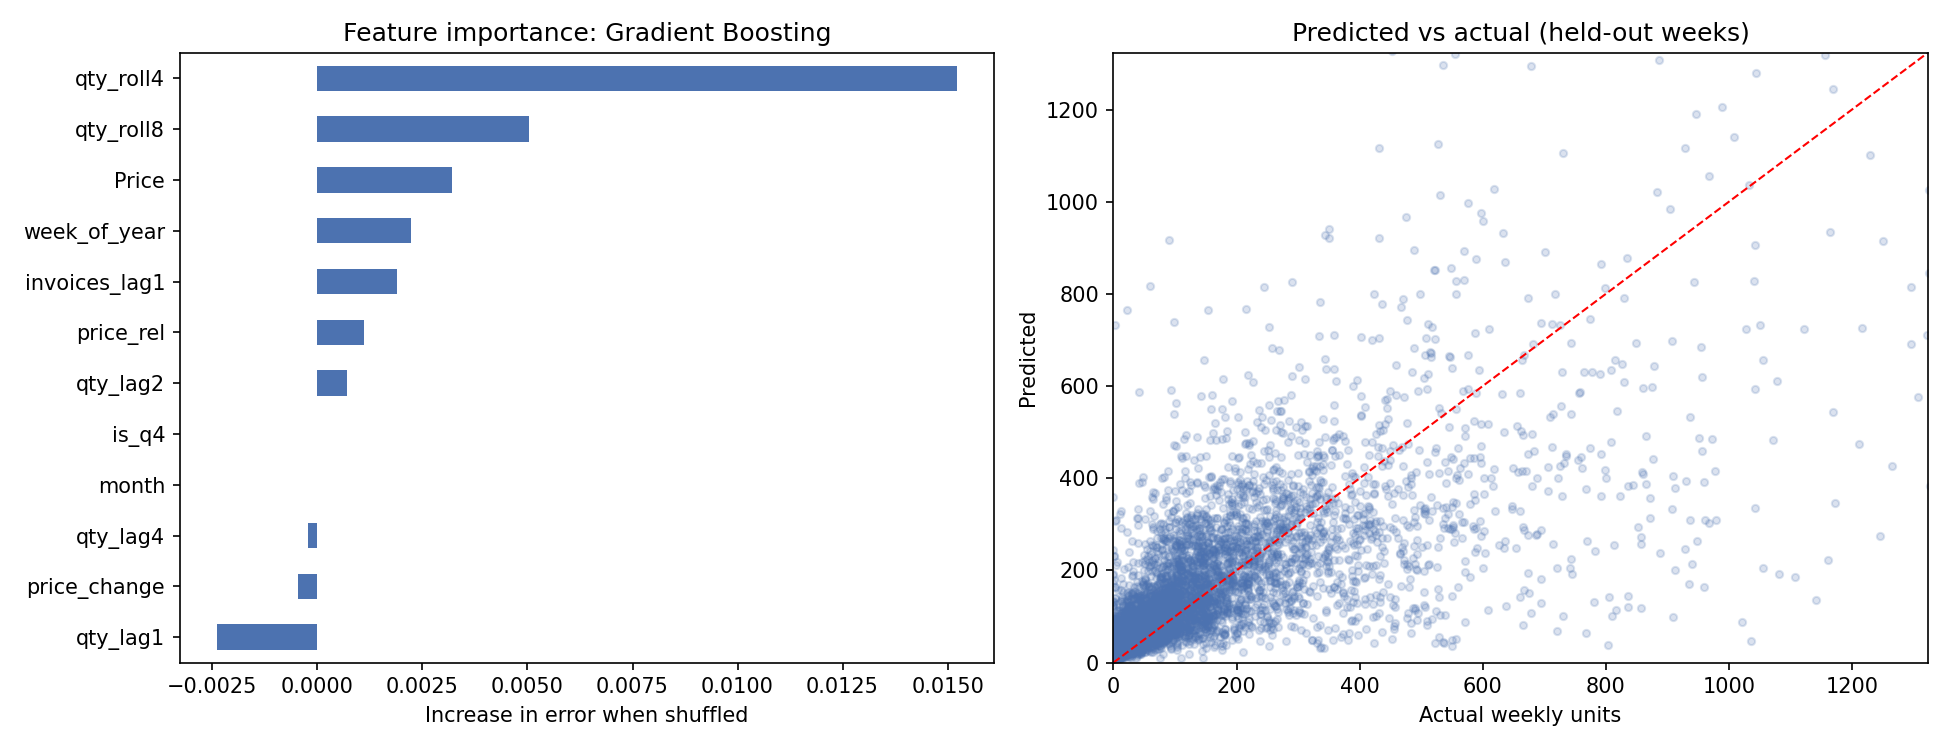

In [27]:
from IPython.display import Image
Image("figures/dataset_a.png")


## 7. Dataset B — session conversion

In [29]:
def run_dataset_b(df):
    d = df.copy()
    d["Revenue"] = d["Revenue"].astype(int)
    d["Weekend"] = d["Weekend"].astype(int)
    y = d["Revenue"]
    X = pd.get_dummies(d.drop(columns=["Revenue"]),
                       columns=["Month", "VisitorType"], drop_first=True)
    print(f"[B] {len(X):,} sessions, {X.shape[1]} features, "
          f"positive rate {y.mean():.1%}")

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=400, min_samples_leaf=2, class_weight="balanced",
            n_jobs=-1, random_state=RANDOM_STATE),
        "Gradient Boosting": HistGradientBoostingClassifier(
            max_iter=400, learning_rate=0.06, random_state=RANDOM_STATE),
    }

    rows = []
    probs = {}
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        prob = model.predict_proba(X_te)[:, 1]
        probs[name] = prob

        prec, rec, thr = precision_recall_curve(y_te, prob)
        f1s = 2 * prec * rec / (prec + rec + 1e-9)
        best_thr = thr[np.argmax(f1s[:-1])]
        pred = (prob >= best_thr).astype(int)

        rows.append({
            "Model": name,
            "PR-AUC": average_precision_score(y_te, prob),
            "ROC-AUC": roc_auc_score(y_te, prob),
            "F1": f1_score(y_te, pred),
            "Threshold": best_thr,
        })
        print(f"\n[B] {name} (threshold {best_thr:.3f})")
        print(classification_report(y_te, pred, target_names=["No purchase", "Purchase"]))
        print("Confusion matrix:\n", confusion_matrix(y_te, pred))

    rows.append({"Model": "Always predict 'no purchase'",
                 "PR-AUC": y_te.mean(), "ROC-AUC": 0.5, "F1": 0.0,
                 "Threshold": np.nan})

    results = pd.DataFrame(rows).set_index("Model").round(3)
    print("\n[B] CONVERSION RESULTS\n", results, "\n")

    best = results.drop(index="Always predict 'no purchase'")["PR-AUC"].idxmax()
    imp = permutation_importance(models[best], X_te, y_te, n_repeats=5,
                                 scoring="average_precision",
                                 random_state=RANDOM_STATE, n_jobs=-1)
    imp_s = (pd.Series(imp.importances_mean, index=X.columns)
               .sort_values().tail(12))
    print(f"[B] permutation importance ({best}):\n", imp_s.round(4), "\n")

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    imp_s.plot.barh(ax=ax[0], color="#DD8452")
    ax[0].set_title(f"Top features: {best}")
    ax[0].set_xlabel("Drop in PR-AUC when shuffled")
    for name, prob in probs.items():
        prec, rec, _ = precision_recall_curve(y_te, prob)
        ax[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_te, prob):.3f})")
    ax[1].axhline(y_te.mean(), ls="--", c="grey", label=f"Base rate ({y_te.mean():.1%})")
    ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precision")
    ax[1].set_title("Precision-recall curve"); ax[1].legend()
    plt.tight_layout(); plt.savefig("figures/dataset_b.png", dpi=150); plt.close()

    return results, imp_s

results_b, importance_b = run_dataset_b(sessions_raw)


[B] 12,330 sessions, 26 features, positive rate 15.5%

[B] Random Forest (threshold 0.325)
              precision    recall  f1-score   support

 No purchase       0.95      0.90      0.93      2606
    Purchase       0.58      0.75      0.66       477

    accuracy                           0.88      3083
   macro avg       0.77      0.83      0.79      3083
weighted avg       0.89      0.88      0.88      3083

Confusion matrix:
 [[2346  260]
 [ 118  359]]

[B] Gradient Boosting (threshold 0.348)
              precision    recall  f1-score   support

 No purchase       0.94      0.94      0.94      2606
    Purchase       0.65      0.65      0.65       477

    accuracy                           0.89      3083
   macro avg       0.79      0.79      0.79      3083
weighted avg       0.89      0.89      0.89      3083

Confusion matrix:
 [[2437  169]
 [ 167  310]]

[B] CONVERSION RESULTS
                               PR-AUC  ROC-AUC     F1  Threshold
Model                            

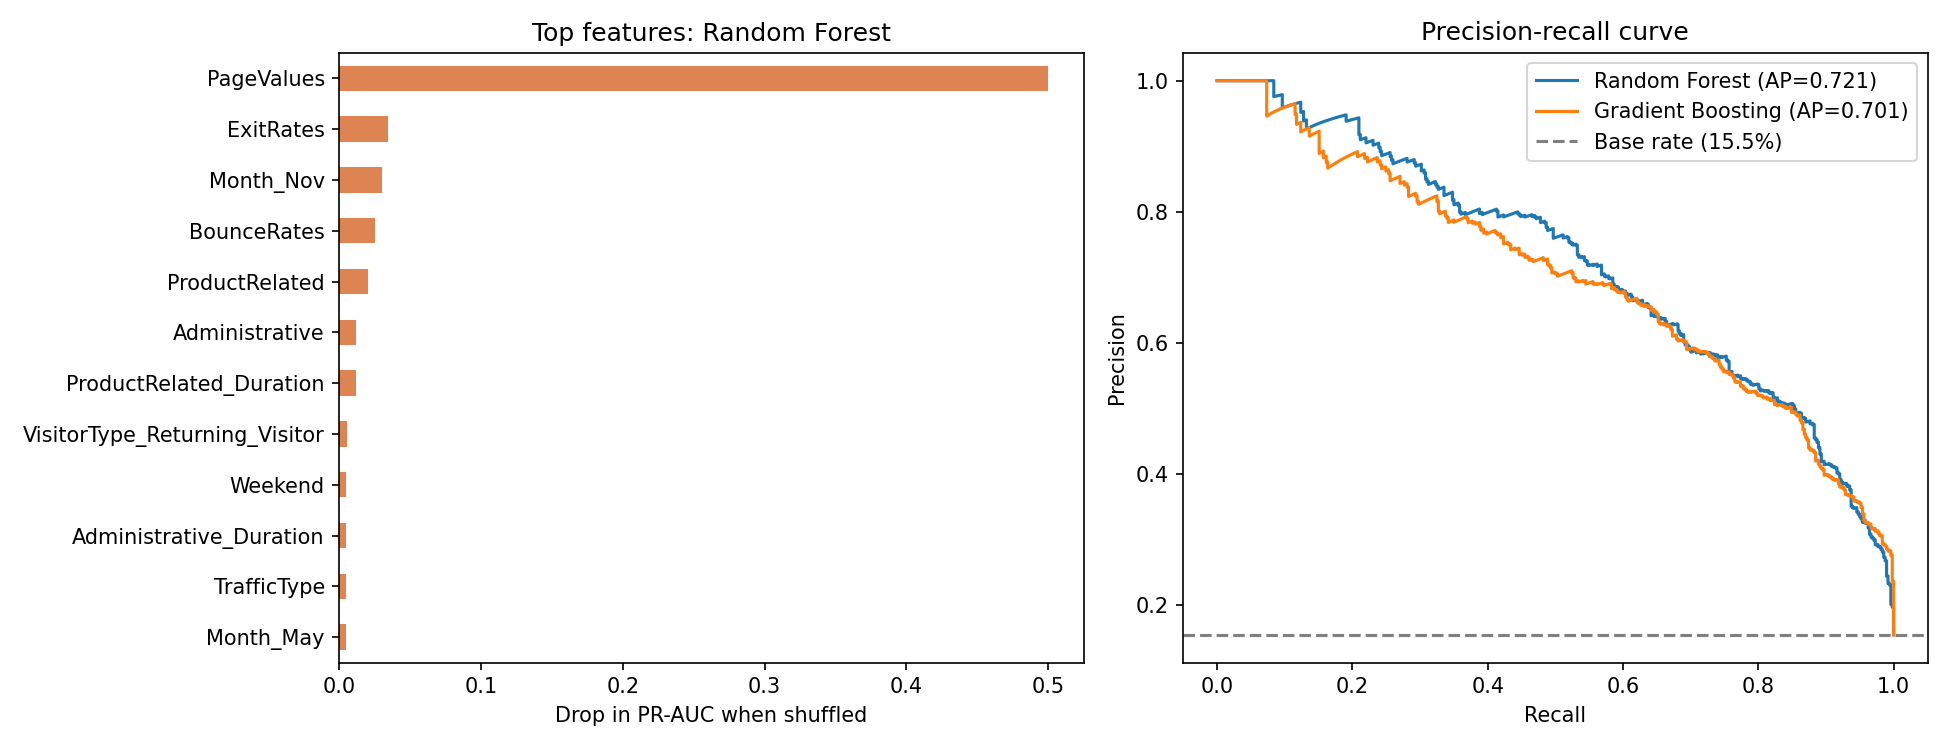

In [30]:
from IPython.display import Image
Image("figures/dataset_b.png")


## 7. Results for the write-up

In [37]:
print("DATASET A — weekly demand forecasting")
display(results_a)
print("\nTop features:")
display(importance_a.sort_values(ascending=False).head(8).round(4))

print("\n" + "="*60)
print("DATASET B — session conversion")
display(results_b)
print("\nTop features:")
display(importance_b.sort_values(ascending=False).head(8).round(4))

results_a.to_csv("results_dataset_a.csv")
results_b.to_csv("results_dataset_b.csv")
print("\nSaved CSVs + figures/ — send these to review the write-up.")


DATASET A — weekly demand forecasting


,MAE,RMSE,WAPE
Model,,,
Naive (lag-1),129.095,1103.695,0.690
Random Forest,113.579,1094.832,0.607
Gradient Boosting,111.235,1095.151,0.595



Top features:


qty_roll4        0.0152
qty_roll8        0.0050
Price            0.0032
week_of_year     0.0022
invoices_lag1    0.0019
price_rel        0.0011
qty_lag2         0.0007
month            0.0000
dtype: float64


DATASET B — session conversion


,PR-AUC,ROC-AUC,F1,Threshold
Model,,,,
Random Forest,0.721,0.922,0.655,0.325
Gradient Boosting,0.701,0.921,0.649,0.348
Always predict 'no purchase',0.155,0.500,0.000,NaN



Top features:


PageValues                       0.5000
ExitRates                        0.0346
Month_Nov                        0.0300
BounceRates                      0.0248
ProductRelated                   0.0201
Administrative                   0.0118
ProductRelated_Duration          0.0115
VisitorType_Returning_Visitor    0.0057
dtype: float64


Saved CSVs + figures/ — send these to review the write-up.
